# Consignación de la base de datos

Construye, capa por capa, la base a nivel **chip/predio** (`gdf_base`) para la zona piloto de dos estaciones (Calle 63-15 y Calle 72-16), integrando: identificación de lotes del piloto, clasificación catastral (destino/uso/PH), geometría del lote, variables de accesibilidad (distancias a metro/viaducto/TM/parques/salud/educación e isócronas), y variables de avalúo/área. El resultado se exporta como `dataset_final_predios_completo.csv`, que es el insumo del notebook `Manipulacion_datos_pre_modelo`. Al final también generan dos tablas de apoyo (*lookups*) para el notebook de análisis de ofertas de mercado.


In [ ]:
!pip install fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 41.1 MB/s eta 0:00:00


### Instalación e imports

Instala `fiona` (necesario para leer capas de algunos formatos geoespaciales) y monta Google Drive. Importa las librerías geoespaciales y numéricas del pipeline y define las rutas fuente: la geodatabase propia (`PATH_GD`), la geodatabase institucional de la UAECD (`PATH_UAECD`, 51GB), el shapefile de estaciones de Transmilenio (`PATH_TM`) y el geopackage con capas auxiliares de la zona piloto (`PATH_GEOPACKAGE`). Se fija el CRS objetivo (`EPSG:6247`) y la lista de estaciones de TM relevantes para el piloto.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── LIBRERÍAS ─────────────────────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd
import numpy as np
import pyogrio
import warnings
import re
import unicodedata
from scipy.spatial.distance import cdist
from shapely.ops import transform
from shapely.geometry import Point
import gc

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.2f}'.format

# ── RUTAS ─────────────────────────────────────────────────────────────────────
PATH_GD          = '/content/drive/MyDrive/Catastro/BaseDatosGD.gdb'
PATH_UAECD       = '/content/drive/MyDrive/Catastro/bd_uaecd_2026.gdb'
PATH_TM          = '/content/drive/MyDrive/Catastro/Predio/Estación_troncal.shp'
PATH_GEOPACKAGE  = '/content/drive/MyDrive/Catastro/Datos_merged/Zona_piloto_GD.gpkg'
CRS_TARGET = 'EPSG:6247'

ESTACIONES_PILOTO = [
    'Calle 85', 'Héroes', 'Polo - FINCOMERCIO', 'Calle 76 - San Felipe',
    'Calle 72', 'Flores – Areandina', 'Calle 63', 'Temporal Calle 57', 'Temporal Marly'
]

Mounted at /content/drive


### Verificación de capas disponibles

Chequeo exploratorio puntual: lista las capas contenidas en el geopackage de la zona piloto, para confirmar los nombres exactos antes de leerlas más adelante.


In [ ]:
import fiona
print(fiona.listlayers('/content/drive/MyDrive/Catastro/Datos_merged/Zona_piloto_GD.gpkg'))

['BaseDatosGD — EstacionesLinea1', 'BaseDatosGD — Lote', 'BaseDatosGD — Lote_frente_via', 'BaseDatosGD — LoteData', 'BaseDatosGD — SueloProtegido', 'BaseDatosGD — TrazadoLinea1', 'Colegios122025', 'Estación_troncal', 'IES', 'ips', 'parques', 'layer_styles', 'BaseDatosGD — Predios_GD']


### Bloque 1 — Predios_GD: universo de lotes del piloto

Carga la capa `Predios_GD` y construye el identificador `barmanpre` concatenando código de barrio, un `'0'` fijo, código de manzana y número de lote — esta es la llave que se usará en todo el pipeline para unir información a nivel lote. El conjunto `barmanpre_piloto` (lotes del piloto) se define aquí y se va refinando (recortando) en varios bloques posteriores conforme se aplican exclusiones.


In [ ]:
# ── BLOQUE 1. PREDIOS_GD ────────────────────────────────────────────────────

df_predios = gpd.read_file(
    PATH_GD,
    layer='Predios_GD',
    engine='pyogrio'
)

# Construir barmanpre = LotCodigo
df_predios['barmanpre'] = (
    df_predios['codigo_barrio'].astype(str).str.strip() +
    '0' +
    df_predios['codigo_manzana'].astype(str).str.strip() +
    df_predios['LOTLNUMERO'].astype(str).str.strip()
)

df_predios = df_predios.copy()

print(f'Filas Predios_GD: {len(df_predios):,}')
print(f'Barmanpre únicos: {df_predios["barmanpre"].nunique():,}')

# Lotes requeridos
barmanpre_piloto = set(df_predios['barmanpre'].unique())

Filas Predios_GD: 103,907
Barmanpre únicos: 17,272


### Bloque 2 — Calificación: variable PH (propiedad horizontal)

Lee de la geodatabase institucional la capa `Calificacion`, que trae `PreUsoPH` (si el chip está bajo régimen de propiedad horizontal) junto con su fecha de calificación (`PreFCalif`). Como un chip puede tener varias calificaciones históricas, se ordena por fecha descendente y se conserva solo la más reciente por chip (`drop_duplicates`).


In [ ]:
# ── BLOQUE 2. CALIFICACION ──────────────────────────────────────────────────

print('\nLeyendo Calificacion...')

df_cal = gpd.read_file(
    PATH_UAECD,
    layer='Calificacion',
    engine='pyogrio',
    columns=['PreChip', 'PreUsoPH', 'PreFCalif']
)

df_cal['PreChip'] = df_cal['PreChip'].astype(str).str.strip()

df_cal['PreUsoPH'] = (
    df_cal['PreUsoPH']
    .astype(str)
    .str.strip()
)

df_cal['PreFCalif'] = pd.to_datetime(
    df_cal['PreFCalif'],
    errors='coerce'
)

# Mantener última calificación por chip
df_cal = (
    df_cal
    .sort_values('PreFCalif', ascending=False)
    .drop_duplicates(subset='PreChip')
    [['PreChip', 'PreUsoPH']]
)

print(f'Chips únicos Calificacion: {len(df_cal):,}')

print('\nDistribución PreUsoPH:')
print(df_cal['PreUsoPH'].value_counts(dropna=False))


Leyendo Calificacion...
Chips únicos Calificacion: 2,872,340

Distribución PreUsoPH:
PreUsoPH
S    2806581
N      65759
Name: count, dtype: int64


### Bloque 2c — Extracción de PreUso (código de uso del suelo)

Lee `PreUso` y `PreAreaUso` de la misma capa `Calificacion`. Un chip puede tener varios registros de uso (p. ej. distintas áreas destinadas a distintos usos); aquí se aplica el criterio de quedarse con el uso que tiene **mayor área asociada** (`PreAreaUso`) por chip, ordenando descendente y tomando el primero.


In [ ]:
# ── BLOQUE 2c. EXTRAER PreUso (criterio: mayor PreAreaUso por chip) ──────────

df_cal_uso = gpd.read_file(
    PATH_UAECD,
    layer='Calificacion',
    engine='pyogrio',
    columns=['PreChip', 'PreUso', 'PreAreaUso']
)

df_cal_uso['PreChip']    = df_cal_uso['PreChip'].astype(str).str.strip()
df_cal_uso['PreAreaUso'] = pd.to_numeric(df_cal_uso['PreAreaUso'], errors='coerce')

df_cal_uso = (
    df_cal_uso
    .sort_values('PreAreaUso', ascending=False)
    .drop_duplicates(subset='PreChip')
    [['PreChip', 'PreUso']]
    .reset_index(drop=True)
)

print(f'Chips con PreUso asignado: {len(df_cal_uso):,}')
print('\nDistribución PreUso:')
print(df_cal_uso['PreUso'].value_counts(dropna=False))

Chips con PreUso asignado: 2,872,340

Distribución PreUso:
PreUso
038    1109410
001     741693
049     453821
037     161334
051     101321
        ...   
082          6
076          6
034          4
052          2
029          1
Name: count, Length: 81, dtype: int64


### Bloque 2d — Mapeo de PreUso: código → descripción

Diccionario de correspondencia entre los códigos numéricos de `PreUso` (tabla oficial de usos del suelo de Catastro) y su descripción textual. Limpia el código (extrae solo dígitos y rellena a 3 caracteres) antes de mapear, y reporta si quedan códigos sin descripción asociada (señal de que el diccionario necesitaría ampliarse).


In [ ]:
# ── BLOQUE 2d. MAPEO PreUso (código → descripción) ──────────────────────────

MAPA_PREUSO = {
    '000': 'Sin Uso', '001': 'Habitacional menor o igual a 3 pisos en NPH',
    '002': 'Habitacional mayor o igual a 4 pisos en NPH', '003': 'Comercio Puntual en NPH',
    '004': 'Corredor Comercial en NPH', '005': 'Estaciones de servicio',
    '006': 'Centro Comercial Mediano NPH', '007': 'Centro Comercial Grande NPH',
    '008': 'Bodega comercial NPH', '009': 'Industria artesanal', '010': 'Industria Mediana',
    '011': 'Industria Grande', '012': 'Institucional Puntual',
    '013': 'Colegios y Universidades de 1 a 3 pisos', '014': 'Iglesias',
    '015': 'Oficinas y Consultorios oficiales en NPH', '016': 'Colegios y Universidades de 4 pisos o más',
    '017': 'Clínicas Hospitales Centro Médicos', '018': 'Instalaciones Militares',
    '019': 'Industria artesanal en PH', '020': 'Oficinas y Consultorios en NPH',
    '021': 'Hoteles en NPH', '022': 'Depósitos de Almacenamiento en NPH',
    '023': 'Teatros y Cinemas en NPH', '024': 'Edificio de Parqueo en NPH',
    '025': 'Bodega de Almacenamiento en NPH', '026': 'Moteles Amoblado y Residencias en NPH',
    '027': 'Moteles Amoblado y Residencias en PH', '028': 'Industria Mediana en PH',
    '029': 'Parques de Diversión en NPH', '030': 'Clubes de Mayor Extensión',
    '031': 'Piscinas en NPH', '032': 'Coliseos', '033': 'Bodega Económica',
    '034': 'Industria Grande en PH', '035': 'Colegios y Universidades de 1 a 3 pisos en PH',
    '036': 'Parques de Diversión en PH', '037': 'Habitacional menor o igual a 3 pisos en PH',
    '038': 'Habitacional mayor o igual a 4 pisos en PH', '039': 'Comercio Puntual en PH',
    '040': 'Corredor Comercial en PH', '041': 'Centro Comercial Mediano en PH',
    '042': 'Centro Comercial Grande en PH', '043': 'Clínicas Hospitales Centro Médicos en PH',
    '044': 'Institucional Puntual en PH', '045': 'Oficinas y Consultorios en PH',
    '046': 'Hoteles en PH', '047': 'Teatros y Cinemas en PH', '048': 'Parqueo libre en PH',
    '049': 'Parqueadero Cubierto en PH', '050': 'Edificio de Parqueo en PH',
    '051': 'Deposito Lockers en PH', '052': 'Piscinas en PH', '053': 'Iglesias en PH',
    '055': 'Cementerios', '056': 'Restaurantes en NPH', '057': 'Área de Mezanine en PH',
    '058': 'Culto Religioso en NPH', '059': 'Culto Religioso en PH', '060': 'Restaurantes en PH',
    '062': 'Pista Aeropuerto', '064': 'Aulas de Clases', '065': 'Clubes Pequeños',
    '066': 'Plazas de Mercado', '067': 'Museos', '070': 'Enramadas Cobertizos Cayenes',
    '071': 'Galpones Gallineros', '072': 'Establos Pesebreras Caballerizas',
    '073': 'Cocheras Marraneras Porquerizas', '074': 'Beneficiadores', '075': 'Secaderos',
    '076': 'Kioscos', '077': 'Silos', '080': 'Oficinas en Bodegas y/o Industrias en NPH',
    '081': 'Oficinas en Bodegas y/o Industrias en PH', '082': 'Oficinas operativas (estaciones de servicio)',
    '090': 'Predios sin construir en PH', '091': 'Bodega comercial en PH',
    '092': 'Oficinas y Consultorios oficiales en PH', '093': 'Bodega de Almacenamiento en PH',
    '094': 'Centro Comercial Pequeño en NPH', '095': 'Centro Comercial Pequeño en PH',
    '096': 'Parqueadero Cubierto en NPH', '097': 'Bodega Económica en PH',
    '098': 'Depósito de Almacenamiento en PH',
}

df_cal_uso['PreUso'] = (
    df_cal_uso['PreUso']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .str.zfill(3)
)
df_cal_uso['PreUso_desc'] = df_cal_uso['PreUso'].map(MAPA_PREUSO)

print('Códigos sin mapeo (revisar):')
print(df_cal_uso.loc[df_cal_uso['PreUso_desc'].isna(), 'PreUso'].value_counts())

print('\nDistribución PreUso_desc:')
print(df_cal_uso['PreUso_desc'].value_counts(dropna=False))

Códigos sin mapeo (revisar):
Series([], Name: count, dtype: int64)

Distribución PreUso_desc:
PreUso_desc
Habitacional mayor o igual a 4 pisos en PH      1109410
Habitacional menor o igual a 3 pisos en NPH      741693
Parqueadero Cubierto en PH                       453821
Habitacional menor o igual a 3 pisos en PH       161334
Deposito Lockers en PH                           101321
                                                 ...   
Oficinas operativas (estaciones de servicio)          6
Kioscos                                               6
Industria Grande en PH                                4
Piscinas en PH                                        2
Parques de Diversión en NPH                           1
Name: count, Length: 81, dtype: int64


### Bloque 3 — Predio UAECD: atributos catastrales a nivel chip

Lee de la geodatabase institucional la capa `Predio`, que aporta estrato, dirección, destino (`PreDestino`) y sector normativo, ya filtrada a los lotes del piloto (`barmanpre_piloto` definido en el Bloque 1).


In [ ]:
# ── BLOQUE 3. PREDIO UAECD (incluye Dirección; ya NO se lee PreCZHF) ───────

print('\nLeyendo Predio UAECD...')

df_predio = gpd.read_file(
    PATH_UAECD,
    layer='Predio',
    engine='pyogrio',
    columns=[
        'Barmanpre',
        'PreChip',
        'PreEstrato',
        'PreDirecc',
        'PreDestino',
        'PreNSector',
        'PreCSector'
    ]
)

df_predio['Barmanpre'] = (
    df_predio['Barmanpre']
    .astype(str)
    .str.strip()
)

# Mantener únicamente lotes del piloto
df_predio = (
    df_predio[
        df_predio['Barmanpre'].isin(barmanpre_piloto)
    ]
    .rename(columns={'Barmanpre': 'barmanpre'})
)

print(f'Predios UAECD piloto: {len(df_predio):,}')
print(f'Lotes únicos UAECD: {df_predio["barmanpre"].nunique():,}')
print(f'Direcciones no nulas: {df_predio["PreDirecc"].notna().sum():,}')


Leyendo Predio UAECD...
Predios UAECD piloto: 103,907
Lotes únicos UAECD: 17,272
Direcciones no nulas: 103,907


### Bloque 3b — Mapeo de PreDestino: código → descripción

Igual que el mapeo de `PreUso` (Bloque 2d), pero para el destino económico del predio (`PreDestino`): residencial, industrial, comercial, dotacional, vías, espacio público, etc. Este mapeo es el que luego se usa para excluir usos públicos no valorables en el bloque siguiente.


In [ ]:
# ── BLOQUE 3b. MAPEO PreDestino (código → descripción) ──────────────────────

MAPA_PREDESTINO = {
    '01': 'Residencial', '03': 'Industrial', '04': 'Dotacional Público',
    '05': 'Recreacional Público', '06': 'Dotacional Privado', '07': 'Minero',
    '08': 'Recreacional Privado', '21': 'Comercio Corredor Comercial',
    '22': 'Comercio Centro Comercial', '23': 'Comercio Puntual', '24': 'Parqueaderos',
    '61': 'Urbanizado No Edificado', '62': 'Urbanizable No Urbanizado',
    '63': 'No Urbanizables y Suelo Protegido', '64': 'Urbanizado No Edificado Propiedad del Estado',
    '65': 'Vías', '66': 'Espacio Público', '67': 'Predios Con Mejoras Ajenas',
    '68': 'Servidumbre Predial', '81': 'Agropecuarios', '82': 'Otros', '83': 'Agrícola',
    '84': 'Pecuario', '85': 'Forestal', '86': 'Agroindustrial', '87': 'Agroforestal',
    '88': 'Tierras Improductivas', '89': 'Predio Rural Con Parcela No Edificada',
}

df_predio['PreDestino'] = (
    df_predio['PreDestino']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .str.zfill(2)
)
df_predio['PreDestino_desc'] = df_predio['PreDestino'].map(MAPA_PREDESTINO)

print('Códigos sin mapeo (revisar):')
print(df_predio.loc[df_predio['PreDestino_desc'].isna(), 'PreDestino'].value_counts())

print('\nDistribución PreDestino_desc:')
print(df_predio['PreDestino_desc'].value_counts(dropna=False))

Códigos sin mapeo (revisar):
Series([], Name: count, dtype: int64)

Distribución PreDestino_desc:
PreDestino_desc
Residencial                                     68707
Comercio Corredor Comercial                     24160
Comercio Centro Comercial                        4664
Comercio Puntual                                 3796
Dotacional Privado                                835
Vías                                              480
Dotacional Público                                436
Espacio Público                                   406
Urbanizado No Edificado                           185
Parqueaderos                                      161
No Urbanizables y Suelo Protegido                  21
Industrial                                         19
Predios Con Mejoras Ajenas                         16
Urbanizado No Edificado Propiedad del Estado       16
Recreacional Privado                                3
Recreacional Público                                2
Name: count, dtype: in

### Bloque 3c — Exclusión de predios de uso público no valorable

Excluye del análisis los predios cuyo destino es Vías (`65`) o Servidumbre Predial (`68`), ya que no son unidades de mercado valorables. `barmanpre_piloto` se recalcula después de este filtro, y esa versión actualizada es la que usan los bloques siguientes.


In [ ]:
# ── BLOQUE 3c. EXCLUIR PREDIOS DE USO PUBLICO NO VALORABLES ────────────────

CODIGOS_USO_PUBLICO = ['65', '68']

mask_excluir = df_predio['PreDestino'].isin(CODIGOS_USO_PUBLICO)

print('Predios a excluir por uso publico (Vias / Servidumbre):')
print(df_predio.loc[mask_excluir, 'PreDestino_desc'].value_counts())

df_predio = df_predio.loc[~mask_excluir].copy()
barmanpre_piloto = set(df_predio['barmanpre'].unique())

print(f'\ndf_predio despues de filtrar Vias/Servidumbre: {len(df_predio):,}')
print(f'barmanpre_piloto actualizado: {len(barmanpre_piloto):,} lotes')


Predios a excluir por uso publico (Vias / Servidumbre):
PreDestino_desc
Vías    480
Name: count, dtype: int64

df_predio despues de filtrar Vias/Servidumbre: 103,427
barmanpre_piloto actualizado: 16,797 lotes


### Bloque 4 — Incorporar PreUsoPH y PreUso a los chips

Une (`merge`, `validate='m:1'`) las tablas de calificación (Bloque 2 y 2c) al dataframe principal de predios por `PreChip`, agregando así la bandera de PH y el uso del suelo a cada chip.


In [ ]:
# ── BLOQUE 4. AGREGAR PreUsoPH A LOS CHIPS ─────────────────────────────────

df_predio = df_predio.merge(
    df_cal,
    on='PreChip',
    how='left',
    validate='m:1'
)
df_predio = df_predio.merge(df_cal_uso, on='PreChip', how='left', validate='m:1')

print('\nDistribución PreUsoPH en chips:')
print(df_predio['PreUsoPH'].value_counts(dropna=False))


Distribución PreUsoPH en chips:
PreUsoPH
S      98166
N       4757
NaN      504
Name: count, dtype: int64


### Bloque 7 — Tabla de correspondencia lote ↔ chip

Genera una tabla auxiliar con la relación `barmanpre` ↔ `PreChip` (y estrato/PH), útil como tabla de referencia rápida para diagnósticos posteriores sin tener que cargar el dataframe completo.


In [ ]:
# ── BLOQUE 7. TABLA BARMANPRE ↔ PRECHIP (sin PreCZHF) ──────────────────────

tabla_chips = (
    df_predio[
        [
            'barmanpre',
            'PreChip',
            'PreEstrato',
            'PreUsoPH'
        ]
    ]
    .drop_duplicates()
    .sort_values(['barmanpre', 'PreChip'])
    .reset_index(drop=True)
)

print(f'Relaciones lote-chip: {len(tabla_chips):,}')

display(tabla_chips.head())

Relaciones lote-chip: 103,427


,barmanpre,PreChip,PreEstrato,PreUsoPH
0,007201001001,AAA0083OXRU,0,S
1,007201001004,AAA0083OXUZ,0,S
2,007201001005,AAA0083OXWF,0,N
3,007201001008,AAA0159XAUZ,0,N
4,007201002001,AAA0083OXZM,0,S


### Bloque 8 — Geometría y centroides del lote

Carga la capa `Lote` (polígonos), la recorta a los lotes del piloto y renombra su identificador a `barmanpre`. Aplana las geometrías 3D a 2D (`aplanar_z`, necesario porque algunas geometrías traen coordenada Z que no aporta información aquí y complica los cálculos de distancia) y reproyecta al CRS objetivo. Calcula el centroide de cada lote (`cx`, `cy`, `centroide`), que es la referencia puntual que usarán todos los cálculos de distancia de los bloques siguientes.


In [ ]:
# ── BLOQUE 8. LOTE — geometría + centroides (SIN decodificación ZHF) ───────

def aplanar_z(geom):
    return transform(lambda x, y, z=None: (x, y), geom)

print('\nLeyendo capa Lote...')
gdf_lote = gpd.read_file(PATH_GD, layer='Lote', engine='pyogrio')
gdf_lote['LOTLOTE_ID'] = gdf_lote['LOTLOTE_ID'].astype(str).str.strip()
gdf_lote = gdf_lote[gdf_lote['LOTLOTE_ID'].isin(barmanpre_piloto)].copy()
gdf_lote = gdf_lote.rename(columns={'LOTLOTE_ID': 'barmanpre'})

# Aplanar geometrías Z y reproyectar
gdf_lote['geometry'] = gdf_lote['geometry'].apply(aplanar_z)
gdf_lote = gdf_lote.set_crs(gdf_lote.crs, allow_override=True).to_crs(CRS_TARGET)

# Centroides
centroides = gdf_lote.geometry.centroid
gdf_lote['cx'] = centroides.x
gdf_lote['cy'] = centroides.y
gdf_lote['centroide'] = centroides

coords_lotes = gdf_lote[['cx', 'cy']].values
print(f'Lotes con geometría: {len(gdf_lote):,}')


Leyendo capa Lote...
Lotes con geometría: 16,797


### Bloque 3d — Filtrado de espacio público (código 66): conservar solo parques

Los predios con destino `66` (Espacio Público) incluyen tanto parques como otras figuras de espacio público que no son comparables en términos de mercado. Aquí se cargan los polígonos oficiales de la capa de parques y se conserva un lote código-66 solo si su geometría **intersecta** esa capa; los que no intersectan (espacio público que no es parque) se excluyen de `df_predio`, `gdf_lote` y de `barmanpre_piloto`, que se refrescan al final del bloque. *(Esta es la validación de la capa de parques contra la fuente oficial que sigue pendiente de confirmar contra IDRD.)*


In [ ]:
# ── BLOQUE 3d. FILTRAR ESPACIO PUBLICO (66): CONSERVAR SOLO PARQUES ────────

# 1. Cargar capa de parques (la misma que usa el Bloque 13 para dist_parques_m)
gdf_parques_ref = gpd.read_file(
    PATH_GEOPACKAGE, layer='parques', engine='pyogrio'
).to_crs(CRS_TARGET)

parques_union = gdf_parques_ref.geometry.unary_union

# 2. Tomar la geometria de los lotes que contienen predios con destino 66
mask_66 = df_predio['PreDestino'] == '66'
barmanpre_66 = df_predio.loc[mask_66, 'barmanpre'].unique()

geom_lotes_66 = (
    gdf_lote[gdf_lote['barmanpre'].isin(barmanpre_66)][['barmanpre', 'geometry']]
    .copy()
)
geom_lotes_66['es_parque'] = geom_lotes_66.geometry.intersects(parques_union)

print(f'Predios codigo 66 (Espacio Publico): {mask_66.sum():,}')
print(f'Lotes unicos con destino 66: {len(geom_lotes_66):,}')
print(f'  -> Intersecan capa de parques (se conservan): {geom_lotes_66["es_parque"].sum():,}')
print(f'  -> NO intersecan parques (se excluyen):       {(~geom_lotes_66["es_parque"]).sum():,}')

# 3. Excluir de df_predio los lotes 66 que NO son parque, y refrescar barmanpre_piloto
barmanpre_excluir = set(geom_lotes_66.loc[~geom_lotes_66['es_parque'], 'barmanpre'])

n_antes = len(df_predio)
df_predio = df_predio[~df_predio['barmanpre'].isin(barmanpre_excluir)].copy()
barmanpre_piloto = set(df_predio['barmanpre'].unique())
gdf_lote = gdf_lote[gdf_lote['barmanpre'].isin(barmanpre_piloto)].copy()
coords_lotes = gdf_lote[['cx', 'cy']].values

print(f'\nPredios excluidos (Espacio Publico no-parques): {n_antes - len(df_predio):,}')
print(f'df_predio final: {len(df_predio):,}')
print(f'gdf_lote final: {len(gdf_lote):,}')
print(f'barmanpre_piloto final: {len(barmanpre_piloto):,} lotes')


Predios codigo 66 (Espacio Publico): 406
Lotes unicos con destino 66: 262
  -> Intersecan capa de parques (se conservan): 90
  -> NO intersecan parques (se excluyen):       172

Predios excluidos (Espacio Publico no-parques): 317
df_predio final: 103,110
gdf_lote final: 16,625
barmanpre_piloto final: 16,625 lotes


### Bloque 9 — Distancias a metro, viaducto y Transmilenio

Calcula tres distancias de accesibilidad desde el centroide de cada lote:
- **Metro** (`dist_estacion_metro_m`): distancia Manhattan (`cityblock`, más realista que la euclidiana para desplazamiento urbano en cuadrícula) al centroide de cada estación de la Línea 1, quedándose con la más cercana y su nombre (`estacion_metro_cercana`).
- **Viaducto** (`dist_viaducto_m`): distancia euclidiana del centroide del lote a la traza completa del viaducto (unión de todas sus geometrías), no a un punto — es una infraestructura lineal, no puntual.
- **Transmilenio** (`dist_tm_m`): igual criterio Manhattan que el metro, pero restringido a las estaciones troncales relevantes para el piloto (`ESTACIONES_PILOTO`).


In [ ]:
# ── BLOQUE 9. DISTANCIAS — Metro, Viaducto, TM ─────────────────────────────

# ── Metro — Manhattan ──────────────────────────────────────────────────────
print('\nCalculando distancias Metro...')

gdf_metro = gpd.read_file(
    PATH_GD,
    layer='EstacionesLinea1',
    engine='pyogrio'
).to_crs(CRS_TARGET)

coords_metro = np.array([
    [g.x, g.y]
    for g in gdf_metro.geometry.centroid
])

nombres_metro = gdf_metro['RefName'].values

mat_metro = cdist(coords_lotes, coords_metro, metric='cityblock')

gdf_lote['dist_estacion_metro_m']   = mat_metro.min(axis=1)
gdf_lote['estacion_metro_cercana']  = nombres_metro[mat_metro.argmin(axis=1)]

print('Distancia metro calculada.')

# ── Viaducto — Euclidiana ──────────────────────────────────────────────────
print('\nCalculando distancia al viaducto...')

gdf_trazado = gpd.read_file(
    PATH_GD,
    layer='TrazadoLinea1',
    engine='pyogrio'
).to_crs(CRS_TARGET)

trazado_union = gdf_trazado.geometry.unary_union

gdf_lote['dist_viaducto_m'] = (
    gdf_lote['centroide'].apply(lambda p: p.distance(trazado_union))
)

print('Distancia viaducto calculada.')

# ── TransMilenio — Manhattan ───────────────────────────────────────────────
print('\nCalculando distancias TM...')

gdf_tm = gpd.read_file(PATH_TM).to_crs(CRS_TARGET)
gdf_tm = gdf_tm[gdf_tm['nom_est'].isin(ESTACIONES_PILOTO)].copy()

coords_tm = np.array([[g.x, g.y] for g in gdf_tm.geometry])
nombres_tm = gdf_tm['nom_est'].values

mat_tm = cdist(coords_lotes, coords_tm, metric='cityblock')

gdf_lote['dist_tm_m']          = mat_tm.min(axis=1)
gdf_lote['estacion_tm_cercana'] = nombres_tm[mat_tm.argmin(axis=1)]

print('Distancia TM calculada.')


Calculando distancias Metro...
Distancia metro calculada.

Calculando distancia al viaducto...
Distancia viaducto calculada.

Calculando distancias TM...
Distancia TM calculada.


### Bloque 9b — Clasificación por isócronas de la Línea 1

Carga los polígonos de isócronas (bandas de tiempo/distancia de caminata alrededor de cada estación) y clasifica cada lote según en qué banda cae, usando como estación de referencia la más cercana ya calculada en el Bloque 9 (comentario en el propio código: esa distancia Manhattan es "la referencia de desempate"). Si el centroide del lote no cae dentro de ninguna banda de ninguna isócrona, se le asigna la banda `'>1200'` como categoría residual. El resultado (`banda_iso_m`, `estacion_iso`, `to_break_m`) es clave para el análisis GWR/espacial posterior.


In [ ]:
# ── BLOQUE 9b. ISOCRONAS METRO LINEA 1 ─────────────────────────────────────
# Requiere que 'estacion_metro_cercana' ya exista en gdf_lote (Bloque 9,
# calculada por distancia Manhattan real — es la referencia de desempate).

PATH_ISOCRONAS = '/content/drive/MyDrive/Catastro/Isocronas/Isócronas.shp'

gdf_iso = gpd.read_file(PATH_ISOCRONAS).to_crs(CRS_TARGET)

MAPA_ESTACION = {15: 'Calle 63', 16: 'Calle 72'}
gdf_iso['estacion'] = gdf_iso['FacilityID'].map(MAPA_ESTACION)
gdf_iso['banda_m']  = gdf_iso.apply(
    lambda r: f"{int(r['FromBreak'])}-{int(r['ToBreak'])}", axis=1
)
gdf_iso = gdf_iso.sort_values('ToBreak').reset_index(drop=True)

print('Capa de isocronas cargada:')
print(gdf_iso[['estacion', 'banda_m', 'FromBreak', 'ToBreak']].to_string())

def clasificar_lote(row):
    punto = row['centroide']
    estacion_ref = row['estacion_metro_cercana']
    polys_estacion = gdf_iso[gdf_iso['estacion'] == estacion_ref]
    for _, iso in polys_estacion.iterrows():
        if iso.geometry.contains(punto):
            return pd.Series({
                'banda_iso_m': iso['banda_m'],
                'estacion_iso': iso['estacion'],
                'to_break_m': iso['ToBreak'],
            })
    return pd.Series({'banda_iso_m': '>1200', 'estacion_iso': estacion_ref, 'to_break_m': None})

clasif = gdf_lote.apply(clasificar_lote, axis=1)
gdf_lote[['banda_iso_m', 'estacion_iso', 'to_break_m']] = clasif

print('\nDistribucion de lotes por banda:')
print(gdf_lote['banda_iso_m'].value_counts())
print('\nDistribucion por estacion de referencia:')
print(gdf_lote['estacion_iso'].value_counts(dropna=False))

Capa de isocronas cargada:
   estacion   banda_m  FromBreak  ToBreak
0  Calle 63     0-400       0.00   400.00
1  Calle 72     0-400       0.00   400.00
2  Calle 72   400-800     400.00   800.00
3  Calle 63   400-800     400.00   800.00
4  Calle 72  800-1200     800.00  1200.00
5  Calle 63  800-1200     800.00  1200.00

Distribucion de lotes por banda:
banda_iso_m
>1200    16625
Name: count, dtype: int64

Distribucion por estacion de referencia:
estacion_iso
Calle 63-15    8490
Calle 72-16    8135
Name: count, dtype: int64


### Bloque 10 — Normalización de direcciones

Define `normalizar_direccion`, un parser de direcciones bajo la nomenclatura vial de Bogotá (tipo de vía + número de vía + número de cruce + placa, con manejo de sufijo `SUR` y de complementos como torre/apartamento/interior que se descartan para el match). El objetivo es producir una clave estandarizada que permita cruzar direcciones textuales de distintas fuentes (IPS, colegios, etc.) contra los lotes del piloto cuando el cruce espacial directo no es suficiente. Direcciones incompletas devuelven `None` (no utilizables para match). Al final se corre una batería de ejemplos de control de calidad sobre el parser antes de aplicarlo a datos reales.


In [ ]:
# ── BLOQUE 10. NORMALIZACIÓN DE DIRECCIONES (nomenclatura Bogotá) ──────────

def normalizar_direccion(direccion):

    if direccion is None or (isinstance(direccion, float) and direccion != direccion):
        return None
    s = str(direccion).upper().strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[#\-\.]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r'(\d+[A-Z]?)\s*BIS\b', r'\1BIS', s)

    complementos = r'\b(TO|TORRE|AP|APTO|APARTAMENTO|CA|CASA|BQ|BLOQUE|IN|INT|INTERIOR|OF|OFICINA|LC|LOCAL|PISO|MZ|MANZANA|ED|EDIFICIO)\b'
    m = re.search(complementos, s)
    base = s[:m.start()].strip() if m else s

    tiene_sur = bool(re.search(r'\bSUR\b', base))
    base_sin_sur = re.sub(r'\bSUR\b', ' ', base)

    tokens = base_sin_sur.split()
    tipo_via = tokens[0] if tokens else None
    numeros = re.findall(r'\d+[A-Z]*', base_sin_sur)
    num_via, num_cruce, placa = (numeros + [None, None, None])[:3]

    if None in (tipo_via, num_via, num_cruce, placa):
        return None  # dirección incompleta, no usable para match

    return f"{tipo_via}_{num_via}_{num_cruce}_{placa}_{'SUR' if tiene_sur else 'N'}"


# Prueba rápida de control de calidad del parser ───────────────────────────
_ejemplos_control = [
    "KR 91C 51 31 SUR", "TV 55A 137 87 TO 1 AP 502",
    "CL 50 SUR 98B 67 CA 127", "CL 42C SUR 73C 30",
    "CL 73 11 95", "KR 15 # 75 54", "CL 65 BIS # 3 - 30",
]
print('Control de calidad del parser de direcciones:')
for e in _ejemplos_control:
    print(f'  {e!r:35} -> {normalizar_direccion(e)}')

Control de calidad del parser de direcciones:
  'KR 91C 51 31 SUR'                  -> KR_91C_51_31_SUR
  'TV 55A 137 87 TO 1 AP 502'         -> TV_55A_137_87_N
  'CL 50 SUR 98B 67 CA 127'           -> CL_50_98B_67_SUR
  'CL 42C SUR 73C 30'                 -> CL_42C_73C_30_SUR
  'CL 73 11 95'                       -> CL_73_11_95_N
  'KR 15 # 75 54'                     -> KR_15_75_54_N
  'CL 65 BIS # 3 - 30'                -> CL_65BIS_3_30_N


### Bloque 11 — Tabla dirección → lote

Aplica `normalizar_direccion` a las direcciones de `df_predio` y arma el diccionario `dir_a_lote` (clave de dirección → `barmanpre`), descartando las claves **ambiguas** (una misma dirección normalizada que corresponde a más de un lote), ya que esos casos no permiten un match confiable.


In [ ]:
# ── BLOQUE 11. TABLA DIRECCIÓN → LOTE (reutiliza barmanpre) ────────────────

df_predio['clave_direccion'] = df_predio['PreDirecc'].apply(normalizar_direccion)

tabla_direcciones_lote = (
    df_predio[['barmanpre', 'clave_direccion']]
    .dropna()
    .drop_duplicates()
)

conteo_lotes_por_clave = tabla_direcciones_lote.groupby('clave_direccion')['barmanpre'].nunique()
claves_ambiguas = conteo_lotes_por_clave[conteo_lotes_por_clave > 1].index

print(f'Direcciones únicas válidas: {tabla_direcciones_lote["clave_direccion"].nunique():,}')
print(f'Lotes con dirección utilizable: {tabla_direcciones_lote["barmanpre"].nunique():,} de {df_predio["barmanpre"].nunique():,}')
print(f'Claves ambiguas (>1 lote, se descartan del match): {len(claves_ambiguas):,}')

dir_a_lote = (
    tabla_direcciones_lote[~tabla_direcciones_lote['clave_direccion'].isin(claves_ambiguas)]
    .set_index('clave_direccion')['barmanpre']
    .to_dict()
)

Direcciones únicas válidas: 18,835
Lotes con dirección utilizable: 16,625 de 16,625
Claves ambiguas (>1 lote, se descartan del match): 93


### Función `corregir_por_direccion`

Función auxiliar reutilizable por las capas de amenidades (IPS, colegios, etc. en el bloque siguiente): dado un GeoDataFrame de puntos con una columna de dirección, intenta reubicar cada punto en el centroide del lote correspondiente cuando su dirección normalizada hace match en `dir_a_lote`. Conserva la geometría original (`geometry_original`) para poder revisar visualmente qué tanto se movió cada punto, y reporta qué porcentaje de la capa quedó "corregida" por este mecanismo.


In [ ]:
def corregir_por_direccion(gdf_amenidad, col_direccion, nombre_capa):
    gdf = gdf_amenidad.copy()
    gdf['geometry_original'] = gdf.geometry  # se conserva para la revisión visual (líneas de corrección)
    gdf['clave_direccion'] = gdf[col_direccion].apply(normalizar_direccion)
    gdf['barmanpre_match'] = gdf['clave_direccion'].map(dir_a_lote)
    gdf['corregido'] = gdf['barmanpre_match'].notna()

    cx_cy = gdf_lote.set_index('barmanpre')[['cx', 'cy']]
    gdf = gdf.merge(cx_cy, left_on='barmanpre_match', right_index=True, how='left')

    gdf['geometry'] = gdf.apply(
        lambda r: Point(r['cx'], r['cy']) if r['corregido'] else r.geometry,
        axis=1
    )

    n = gdf['corregido'].sum()
    print(f'{nombre_capa}: {n:,} de {len(gdf):,} reubicados por dirección ({n/len(gdf)*100:.1f}%)')
    return gpd.GeoDataFrame(gdf, geometry='geometry', crs=CRS_TARGET)

### Bloque 13 — Distancias a salud, educación y parques

Carga las capas de IPS (salud), colegios, IES (educación superior) y parques, reproyectadas al CRS objetivo, y calcula tres distancias Manhattan desde el centroide de cada lote:
- **Salud** (`dist_salud_m`): además del cálculo de distancia estándar, fuerza distancia `0` para los lotes que tienen un match directo por dirección/código a una IPS (`lotcodigo` reconstruido con `zfill(12)` porque el shapefile lo guarda como campo numérico y pierde los ceros a la izquierda).
- **Educación** (`dist_educacion_m`): distancia mínima combinando colegios e IES en un solo conjunto de puntos.
- **Parques** (`dist_parques_m`): distancia del centroide del lote al polígono unido de todos los parques (no a un punto).


In [ ]:
# ── BLOQUE 13. GEOPACKAGE — IPS / COLEGIOS / IES / PARQUES + DISTANCIAS ────


PATH_IPS_NUEVO = '/content/drive/MyDrive/Catastro/IPS/salida.shp'

gdf_ips      = gpd.read_file(PATH_IPS_NUEVO).to_crs(CRS_TARGET)
gdf_colegios = gpd.read_file(PATH_GEOPACKAGE, layer='colegios122025', engine='pyogrio').to_crs(CRS_TARGET)
gdf_ies      = gpd.read_file(PATH_GEOPACKAGE, layer='IES', engine='pyogrio').to_crs(CRS_TARGET)
gdf_parques  = gpd.read_file(PATH_GEOPACKAGE, layer='parques', engine='pyogrio').to_crs(CRS_TARGET)

# Llave de match: lotcodigo -> barmanpre (agregar los '00' iniciales que
# se pierden porque el shapefile guarda lotcodigo como campo numérico)
gdf_ips['barmanpre_match'] = (
    gdf_ips['lotcodigo'].astype('int64').astype(str).str.zfill(12)
)

# ── Salud (IPS) ──────────────────────────────────────────────────────────
coords_salud = np.array([[g.x, g.y] for g in gdf_ips.geometry])
gdf_lote['dist_salud_m'] = cdist(coords_lotes, coords_salud, metric='cityblock').min(axis=1)

lotes_con_ips = set(gdf_ips['barmanpre_match'].dropna())
n_forzados = gdf_lote['barmanpre'].isin(lotes_con_ips).sum()
gdf_lote.loc[gdf_lote['barmanpre'].isin(lotes_con_ips), 'dist_salud_m'] = 0.0

print(f'Lotes con match directo a IPS (dist forzada a 0): {n_forzados:,} de {len(gdf_lote):,}')
print(f'IPS sin match a ningún barmanpre de la zona piloto: '
      f'{gdf_ips["barmanpre_match"].isin(gdf_lote["barmanpre"]).eq(False).sum():,} de {len(gdf_ips):,}')

# ── Educación (colegios + IES) ────────────────────────────────────────────
coords_educacion = np.array([
    [g.x, g.y] for g in pd.concat([gdf_colegios, gdf_ies]).geometry
])
gdf_lote['dist_educacion_m'] = cdist(coords_lotes, coords_educacion, metric='cityblock').min(axis=1)

# ── Parques — polígono ────────────────────────────────────────────────────
parques_union_dist = gdf_parques.geometry.unary_union
gdf_lote['dist_parques_m'] = gdf_lote['centroide'].apply(lambda p: p.distance(parques_union_dist))

print('\nDistancias salud / educacion / parques calculadas.')
print(gdf_lote[['dist_salud_m', 'dist_educacion_m', 'dist_parques_m']].describe())


Lotes con match directo a IPS (dist forzada a 0): 230 de 16,625
IPS sin match a ningún barmanpre de la zona piloto: 20 de 374

Distancias salud / educacion / parques calculadas.
       dist_salud_m  dist_educacion_m  dist_parques_m
count      16625.00          16625.00        16625.00
mean            inf            228.72          160.11
std             NaN            136.32          107.67
min            0.00              6.45            0.00
25%             NaN            124.26           76.11
50%             NaN            202.30          139.45
75%             NaN            311.73          227.89
max             inf            909.42          687.25


### Bloque 14 — Recarga de LoteData (área y avalúo)

Vuelve a leer la capa `LoteData`, esta vez solo con las columnas de área de terreno, área construida y valor de avalúo 2026, filtrando a los lotes del piloto y eliminando duplicados por `barmanpre`.


In [ ]:
# ── BLOQUE 14. RECARGAR LOTEDATA ───────────────────────────────────────────

print('Leyendo LoteData...')

df_lotedata = gpd.read_file(
    PATH_GD,
    layer='LoteData',
    engine='pyogrio',
    columns=[
        'barmanpre',
        'area_terreno_2026',
        'area_construida_2026',
        'valor_avaluo_2026'
    ]
)

df_lotedata['barmanpre'] = (
    df_lotedata['barmanpre']
    .astype(str)
    .str.strip()
)

df_lotedata = (
    df_lotedata[
        df_lotedata['barmanpre'].isin(barmanpre_piloto)
    ]
    .drop_duplicates(subset='barmanpre')
    .copy()
)

print(f'Lotes en LoteData: {len(df_lotedata):,}')
display(df_lotedata.head())

Leyendo LoteData...
Lotes en LoteData: 16,625


,barmanpre,area_terreno_2026,area_construida_2026,valor_avaluo_2026,geometry
0,007403010006,160.80,281.36,760135000.00,"MULTIPOLYGON Z (((101410.224 107508.515 0, 101..."
1,008314015002,1.00,12.60,37410000.00,"MULTIPOLYGON Z (((102210.113 108172.451 0, 102..."
2,008306022005,4.93,13.70,37410000.00,"MULTIPOLYGON Z (((102412.077 106607.425 0, 102..."
3,008213008005,18.10,52.00,426221000.00,"MULTIPOLYGON Z (((101408.586 105526.297 0, 101..."
4,008213025010,64.39,91.80,274865000.00,"MULTIPOLYGON Z (((101772.613 105711.875 0, 101..."


### Verificación de columnas categóricas

Chequeo de control de calidad: confirma que `df_predio` efectivamente tiene las columnas categóricas esperadas (destino, uso, sector) y reporta sus nulos, antes de construir la base final en el bloque siguiente.


In [ ]:
# Verificar que df_predio tiene las variables categoricas que esperamos
print('Columnas de df_predio:')
print(df_predio.columns.tolist())
print()
print('Deberian estar presentes:')
esperadas = ['PreDestino','PreDestino_desc','PreUso','PreUso_desc','PreNSector','PreCSector']
for col in esperadas:
    presente = col in df_predio.columns
    n_nulos = df_predio[col].isna().sum() if presente else 'N/A'
    print(f'  {col:20s}: presente={presente}  nulos={n_nulos}')

Columnas de df_predio:
['PreChip', 'PreNSector', 'PreCSector', 'PreDirecc', 'PreDestino', 'PreEstrato', 'barmanpre', 'PreDestino_desc', 'PreUsoPH', 'PreUso', 'PreUso_desc', 'clave_direccion']

Deberian estar presentes:
  PreDestino          : presente=True  nulos=0
  PreDestino_desc     : presente=True  nulos=0
  PreUso              : presente=True  nulos=349
  PreUso_desc         : presente=True  nulos=349
  PreNSector          : presente=True  nulos=0
  PreCSector          : presente=True  nulos=0


### Bloque 15 — Construcción de la base final a nivel predio

Une (`merge`, `validate='m:1'` en ambos casos) `df_predio` con las variables de área/avalúo (`vars_lotedata`) y con las variables geométricas y de accesibilidad del lote (`vars_lote`), todo por `barmanpre`. El resultado, `gdf_base`, es la base final a nivel predio/chip que se exportará en los bloques siguientes — nótese en el comentario del propio código que esta versión ya **no** incluye las variables ZHF (`PreCZHF`), que quedaron pendientes de corrección según lo documentado en el notebook de modelado.


In [ ]:
# ── BLOQUE 15. CONSTRUIR BASE FINAL A NIVEL PREDIO (sin variables ZHF) ─────

vars_lote = [
    'barmanpre',
    'geometry',
    'centroide',
    'cx',
    'cy',
    'dist_estacion_metro_m',
    'estacion_metro_cercana',
    'dist_viaducto_m',
    'dist_tm_m',
    'estacion_tm_cercana',
    'dist_parques_m',
    'dist_salud_m',
    'dist_educacion_m',
    'banda_iso_m',
    'estacion_iso',
    'to_break_m',
]

vars_lotedata = [
    'barmanpre',
    'area_terreno_2026',
    'area_construida_2026',
    'valor_avaluo_2026'
]

gdf_base = (
    df_predio
    .merge(df_lotedata[vars_lotedata], on='barmanpre', how='left', validate='m:1')
    .merge(gdf_lote[vars_lote],        on='barmanpre', how='left', validate='m:1')
)

gdf_base = gpd.GeoDataFrame(gdf_base, geometry='geometry', crs=CRS_TARGET)

print(f'\nFilas base final: {len(gdf_base):,}')
print(f'Chips únicos: {gdf_base["PreChip"].nunique():,}')
print(f'Lotes únicos: {gdf_base["barmanpre"].nunique():,}')

print('\nDistribución PH:')
print(gdf_base['PreUsoPH'].value_counts(dropna=False))

display(
    gdf_base[
        [
            'barmanpre', 'PreChip', 'PreUsoPH', 'PreEstrato',
            'area_terreno_2026', 'area_construida_2026', 'valor_avaluo_2026',
            'dist_estacion_metro_m', 'dist_salud_m', 'dist_educacion_m', 'dist_parques_m','banda_iso_m','estacion_iso','to_break_m'
        ]
    ].head()
)


Filas base final: 103,110
Chips únicos: 103,110
Lotes únicos: 16,625

Distribución PH:
PreUsoPH
S      98005
N       4756
NaN      349
Name: count, dtype: int64


,barmanpre,PreChip,PreUsoPH,PreEstrato,area_terreno_2026,area_construida_2026,valor_avaluo_2026,dist_estacion_metro_m,dist_salud_m,dist_educacion_m,dist_parques_m,banda_iso_m,estacion_iso,to_break_m
0,008205049002,AAA0158NFUZ,NaN,0,0.00,35.02,13229000.00,1508.81,inf,539.35,30.09,>1200,Calle 63-15,None
1,008205049002,AAA0158NFWF,S,2,0.00,35.02,13229000.00,1508.81,inf,539.35,30.09,>1200,Calle 63-15,None
2,008205049002,AAA0158NFXR,S,2,0.00,35.02,13229000.00,1508.81,inf,539.35,30.09,>1200,Calle 63-15,None
3,008205049002,AAA0158NFYX,S,2,0.00,35.02,13229000.00,1508.81,inf,539.35,30.09,>1200,Calle 63-15,None
4,008205049002,AAA0158NHAF,S,2,0.00,35.02,13229000.00,1508.81,inf,539.35,30.09,>1200,Calle 63-15,None


### Verificación de columnas en gdf_base

Mismo chequeo del bloque anterior, pero ya sobre `gdf_base`, para confirmar que las columnas categóricas sobrevivieron a los merges.


In [ ]:
# En el notebook de consignacion, DESPUES del Bloque 15
print('Columnas de gdf_base:')
print(gdf_base.columns.tolist())
print()
for col in ['PreDestino','PreDestino_desc','PreUso','PreUso_desc','PreNSector','PreCSector']:
    print(f'  {col:20s}: {"presente" if col in gdf_base.columns else "AUSENTE"}')

Columnas de gdf_base:
['PreChip', 'PreNSector', 'PreCSector', 'PreDirecc', 'PreDestino', 'PreEstrato', 'barmanpre', 'PreDestino_desc', 'PreUsoPH', 'PreUso', 'PreUso_desc', 'clave_direccion', 'area_terreno_2026', 'area_construida_2026', 'valor_avaluo_2026', 'geometry', 'centroide', 'cx', 'cy', 'dist_estacion_metro_m', 'estacion_metro_cercana', 'dist_viaducto_m', 'dist_tm_m', 'estacion_tm_cercana', 'dist_parques_m', 'dist_salud_m', 'dist_educacion_m', 'banda_iso_m', 'estacion_iso', 'to_break_m']

  PreDestino          : presente
  PreDestino_desc     : presente
  PreUso              : presente
  PreUso_desc         : presente
  PreNSector          : presente
  PreCSector          : presente


### Bloque 16 — Exportación a CSV

Convierte la geometría a WKT (texto) para poder guardar en formato plano, y exporta `gdf_base` como `dataset_final_predios_completo.csv` — este es el archivo que consume directamente el notebook `Manipulacion_datos_pre_modelo`.


In [ ]:
# ── BLOQUE 16. EXPORTAR CSV  ──────────────────────────────

dataset_csv = gdf_base.copy()
dataset_csv['geometry'] = dataset_csv.geometry.to_wkt()

if 'centroide' in dataset_csv.columns:
    dataset_csv['centroide'] = dataset_csv['centroide'].astype(str)

dataset_csv = pd.DataFrame(dataset_csv)
gc.collect()

dataset_csv.to_csv(
    'dataset_final_predios_completo.csv',
    index=False,
    encoding='utf-8-sig',
    chunksize=50000
)

print('CSV exportado correctamente.')
print(f'Filas: {len(dataset_csv):,}')
print(f'Columnas: {len(dataset_csv.columns):,}')
display(dataset_csv.head())

CSV exportado correctamente.
Filas: 103,110
Columnas: 30


,PreChip,PreNSector,PreCSector,PreDirecc,PreDestino,PreEstrato,barmanpre,PreDestino_desc,PreUsoPH,PreUso,...,estacion_metro_cercana,dist_viaducto_m,dist_tm_m,estacion_tm_cercana,dist_parques_m,dist_salud_m,dist_educacion_m,banda_iso_m,estacion_iso,to_break_m
0,AAA0158NFUZ,MARIA CRISTINA,008205,CL 62 1F 05,63,0,008205049002,No Urbanizables y Suelo Protegido,NaN,NaN,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None
1,AAA0158NFWF,MARIA CRISTINA,008205,CL 62 1F 05 MJ 1,01,2,008205049002,Residencial,S,001,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None
2,AAA0158NFXR,MARIA CRISTINA,008205,CL 62 1F 05 MJ 2,01,2,008205049002,Residencial,S,001,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None
3,AAA0158NFYX,MARIA CRISTINA,008205,CL 62 1F 05 MJ 3,01,2,008205049002,Residencial,S,001,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None
4,AAA0158NHAF,MARIA CRISTINA,008205,CL 62 1F 05 MJ 5,01,2,008205049002,Residencial,S,001,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None


### Bloque 16 — Exportación a XLSX

Misma exportación que la celda anterior, pero en formato Excel, como copia de respaldo/consulta manual.


In [ ]:
# ── BLOQUE 16. EXPORTAR XLSX ──────────────────────────────

dataset_xlsx = gdf_base.copy()

dataset_xlsx['geometry'] = dataset_xlsx.geometry.to_wkt()

if 'centroide' in dataset_xlsx.columns:
    dataset_xlsx['centroide'] = dataset_xlsx['centroide'].astype(str)

dataset_xlsx = pd.DataFrame(dataset_xlsx)
gc.collect()

dataset_xlsx.to_excel(
    'dataset_final_predios_completo.xlsx',
    index=False,
    engine='openpyxl'
)

print('XLSX exportado correctamente.')
print(f'Filas: {len(dataset_xlsx):,}')
print(f'Columnas: {len(dataset_xlsx.columns):,}')

display(dataset_xlsx.head())

XLSX exportado correctamente.
Filas: 103,110
Columnas: 30


,PreChip,PreNSector,PreCSector,PreDirecc,PreDestino,PreEstrato,barmanpre,PreDestino_desc,PreUsoPH,PreUso,...,estacion_metro_cercana,dist_viaducto_m,dist_tm_m,estacion_tm_cercana,dist_parques_m,dist_salud_m,dist_educacion_m,banda_iso_m,estacion_iso,to_break_m
0,AAA0158NFUZ,MARIA CRISTINA,008205,CL 62 1F 05,63,0,008205049002,No Urbanizables y Suelo Protegido,NaN,NaN,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None
1,AAA0158NFWF,MARIA CRISTINA,008205,CL 62 1F 05 MJ 1,01,2,008205049002,Residencial,S,001,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None
2,AAA0158NFXR,MARIA CRISTINA,008205,CL 62 1F 05 MJ 2,01,2,008205049002,Residencial,S,001,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None
3,AAA0158NFYX,MARIA CRISTINA,008205,CL 62 1F 05 MJ 3,01,2,008205049002,Residencial,S,001,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None
4,AAA0158NHAF,MARIA CRISTINA,008205,CL 62 1F 05 MJ 5,01,2,008205049002,Residencial,S,001,...,Calle 63-15,1061.54,1211.35,Temporal Calle 57,30.09,inf,539.35,>1200,Calle 63-15,None


## Comprobación visual de la base final

<Axes: >

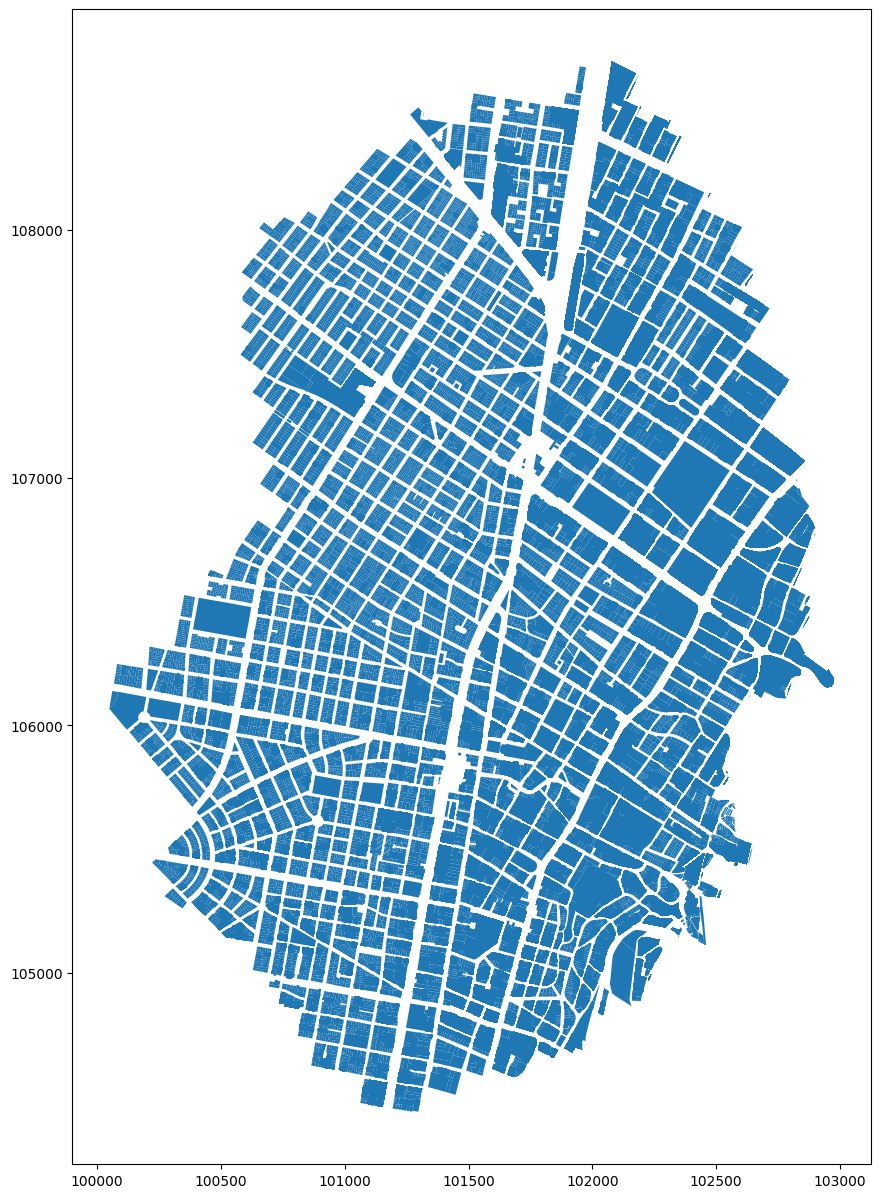

In [ ]:
gdf_base.plot(figsize=(15, 15), linewidth=0.1)

### Clasificación de isócronas para el lookup de ofertas

Repite la lógica de clasificación por isócrona del Bloque 9b, pero con nombres de estación específicos para el notebook de ofertas (`'Calle 63-15'`, `'Calle 72-16'`) y guardando el resultado en un dataframe temporal aparte — el comentario del propio código aclara que esto **no** modifica `gdf_lote` ni `gdf_base`, para no afectar los notebooks de manipulación y modelado. El resultado se exporta como `lookup_chip_isocrona.csv`.


In [ ]:
# Clasificación corregida SOLO para el lookup de ofertas.
# No modifica gdf_lote ni gdf_base — Manipulacion y Modelos_de_valor quedan intactos.
MAPA_ESTACION_OFERTAS = {15: 'Calle 63-15', 16: 'Calle 72-16'}
gdf_iso_ofertas = gdf_iso.copy()
gdf_iso_ofertas['estacion'] = gdf_iso_ofertas['FacilityID'].map(MAPA_ESTACION_OFERTAS)

def clasificar_lote_ofertas(row):
    punto = row['centroide']
    estacion_ref = row['estacion_metro_cercana']
    polys_estacion = gdf_iso_ofertas[gdf_iso_ofertas['estacion'] == estacion_ref]
    for _, iso in polys_estacion.iterrows():
        if iso.geometry.contains(punto):
            return pd.Series({'banda_iso_m_ofertas': iso['banda_m'], 'estacion_iso_ofertas': iso['estacion']})
    return pd.Series({'banda_iso_m_ofertas': '>1200', 'estacion_iso_ofertas': estacion_ref})

clasif_ofertas = gdf_lote.apply(clasificar_lote_ofertas, axis=1)
gdf_lote_ofertas_tmp = gdf_lote[['barmanpre']].join(clasif_ofertas)

print(gdf_lote_ofertas_tmp['banda_iso_m_ofertas'].value_counts())

# Lookup Chip -> banda, uniendo por barmanpre (gdf_base no se modifica, solo se lee)
lookup_iso = (
    gdf_base[['PreChip', 'barmanpre']]
    .merge(gdf_lote_ofertas_tmp, on='barmanpre', how='left')
    .drop_duplicates()
)

lookup_iso.to_csv(
    '/content/drive/MyDrive/Catastro/CSV_Ofertas/lookup_chip_isocrona.csv',
    index=False, encoding='utf-8-sig'
)
print(f'Lookup exportado: {len(lookup_iso):,} chips')
print(lookup_iso['banda_iso_m_ofertas'].value_counts(dropna=False))

banda_iso_m_ofertas
800-1200    6401
400-800     4591
>1200       4168
0-400       1465
Name: count, dtype: int64
Lookup exportado: 103,110 chips
banda_iso_m_ofertas
800-1200    35691
>1200       28704
400-800     28551
0-400       10164
Name: count, dtype: int64


### Lookup Chip -> PH/NPH, para el notebook de ofertas


In [ ]:
# ── Lookup Chip -> PH/NPH, para segmentar el mercado de ofertas ──────────
lookup_ph = gdf_base[['PreChip', 'barmanpre', 'PreUsoPH']].drop_duplicates().copy()
lookup_ph['es_PH'] = (lookup_ph['PreUsoPH'].astype(str).str.upper() == 'S').astype(int)

lookup_ph.to_csv(
    '/content/drive/MyDrive/Catastro/CSV_Ofertas/lookup_chip_ph.csv',
    index=False, encoding='utf-8-sig'
)
print(f'Lookup exportado: {len(lookup_ph):,} chips')
print(lookup_ph['es_PH'].value_counts(dropna=False))


Lookup exportado: 103,110 chips
es_PH
1    98005
0     5105
Name: count, dtype: int64
